# ICT-8 — Paysages d'attracteurs & signaux precurseurs : *les deux tressees*

> **Serie ICT** (Integrated Causal Trajectories, Epic #4588) — strate 2 : *morphogenese dynamique*.
> Prerequis conseilles : [ICT-0-Framing](ICT-0-Framing.md), et les notebooks de causal emergence
> [ICT-5](ICT-5-CausalEmergence.ipynb) / [ICT-6](ICT-6-SortingToTPM-CausalEmergence.ipynb).

## Pourquoi monter d'un cran

La strate 1 de la serie (le **tri auto-organise**, ICT-2 a ICT-7) etait le bon marche-pied :
transparente, calculable, et deja porteuse de « competences inattendues » reelles. Mais elle bute
sur trois limites pour qui veut voir apparaitre l'**agence** et l'**organisation multi-echelle** :

1. un **attracteur global unique**, dont le but (le tableau trie) est **impose de l'exterieur** ;
2. **aucun point de consigne intrinseque** — rien que le systeme « cherche » de lui-meme ;
3. **pas de hierarchie generatrice** — la richesse multi-echelle y est *analytique*, pas produite par
   la dynamique.

Ce notebook ouvre la strate 2 sur un substrat qui leve la premiere et la troisieme limite : un
**systeme bistable a bifurcation pli**. ICT-9 levera la deuxieme (l'agence comme regeneration vers
une consigne).

## Le principe : *les deux tressees*

Tout au long de ce notebook, deux fils sont **tresses** :

- **le fil metaphorique** — un *paysage* avec des vallees, une *bascule catastrophique*, une *memoire*
  de la proximite du desastre ;
- **le fil de la mesure** — **chaque** image est adossee a une grandeur calculee sur un **vrai modele**
  (equilibres, potentiel effectif, valeur propre, variance, autocorrelation, tau de Kendall).

La metaphore n'est creditee qu'au vu de ce qu'une mesure explicite en montre — c'est la traduction
directe de la these de Levin : *les revendications cognitives sont des revendications de protocole*.
On verra meme, sans complaisance, qu'une **mesure naive fabrique ou masque** le signal : la credibilite
de la metaphore tient entierement a la **rigueur du protocole**.


In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
from ict.bistable import GrazingModel
from ict import early_warning as ew

GRAINE = 8  # reproductibilite
np.random.seed(GRAINE)

modele = GrazingModel(r=1.0, K=10.0, h=1.0)
c_fold = modele.find_fold(1.5, 3.5, n=4000)
print(f"Modele de paturage de May (1977) : r={modele.r}, K={modele.K}, h={modele.h}")
print(f"Bifurcation pli localisee a  c_fold ~= {c_fold:.3f}")

Modele de paturage de May (1977) : r=1.0, K=10.0, h=1.0
Bifurcation pli localisee a  c_fold ~= 2.604


## 1. Le modele — paturage de May (1977)

On etudie une biomasse de vegetation $x$ broutee a une pression $c$ :

$$\frac{dx}{dt} \;=\; \underbrace{r\,x\Big(1-\frac{x}{K}\Big)}_{\text{croissance logistique}} \;-\; \underbrace{c\,\frac{x^2}{x^2+h^2}}_{\text{broutage (reponse de type III)}}$$

C'est **le** systeme canonique de la litterature des *early-warning signals* (Scheffer et al., *Nature*
2009 ; Dakos et al. 2012). Sa structure, pour $c$ faible, est celle des **etats stables alternatifs** :

- un etat **vegetalise haut** ($x$ eleve) et un etat **surpature bas** ($x$ faible) **coexistent**,
  separes par un equilibre **instable** (le col) ;
- l'etat vraiment vide $x=0$ est, lui, **instable** : la reponse de broutage s'annule en $x^2$ pres de
  zero, donc la vegetation repart toujours du quasi-neant.

Quand la pression $c$ franchit un seuil $c_\text{fold}$, l'etat haut et le col **fusionnent et
disparaissent** (le *pli*) : le systeme bascule **catastrophiquement** vers l'etat bas. C'est un
*changement de regime*, pas une extinction — et c'est exactement le genre de transition qu'on aimerait
**voir venir**.


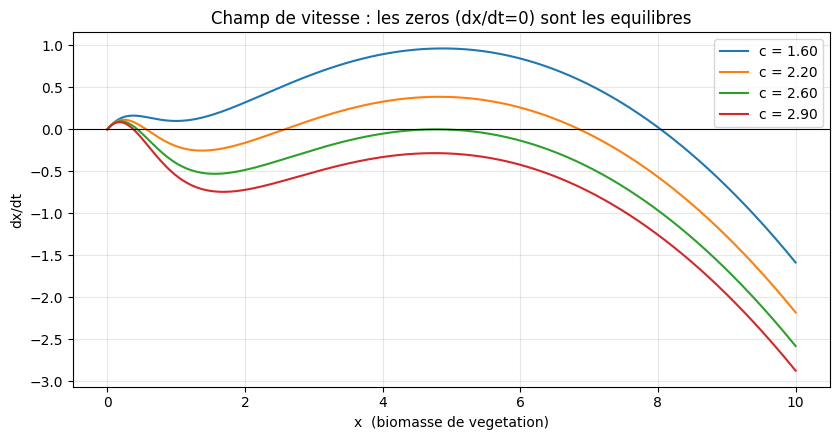

c=1.80 : equilibres [0.00(i), 1.00(s), 1.30(i), 7.70(s)]   (s=stable, i=instable)
c=2.60 : equilibres [0.00(i), 0.44(s), 4.75(i), 4.81(s)]   (s=stable, i=instable)
c=3.20 : equilibres [0.00(i), 0.34(s)]   (s=stable, i=instable)


In [2]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
xs = np.linspace(0, 10, 400)
for c in [1.6, 2.2, c_fold, 2.9]:
    ax.plot(xs, modele.rate(xs, c), label=f"c = {c:.2f}")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("x  (biomasse de vegetation)"); ax.set_ylabel("dx/dt")
ax.set_title("Champ de vitesse : les zeros (dx/dt=0) sont les equilibres")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for c in (1.8, c_fold, 3.2):
    eqs = modele.equilibria(c)
    desc = ", ".join(f"{x:.2f}{'(s)' if st else '(i)'}" for x, st in eqs)
    print(f"c={c:.2f} : equilibres [{desc}]   (s=stable, i=instable)")

## 2. Le paysage d'attracteurs

Le modele derive d'un **potentiel effectif** $V(x)$ tel que $\dfrac{dx}{dt} = -\dfrac{dV}{dx}$ :

$$V(x) = -\frac{r x^2}{2} + \frac{r x^3}{3K} + c\,x - c\,h\,\arctan\!\frac{x}{h}.$$

Ce potentiel n'est **pas** ajuste a la main : il est l'antiderivee exacte du champ. Ses **minima sont
les attracteurs** (les vallees ou la bille se repose), son **maximum local est le col** qui les separe.
A gauche, on voit le **puits haut s'aplatir** a mesure que $c$ augmente ; a droite, le **diagramme de
bifurcation** montre les branches stables et instable se rejoindre au pli.


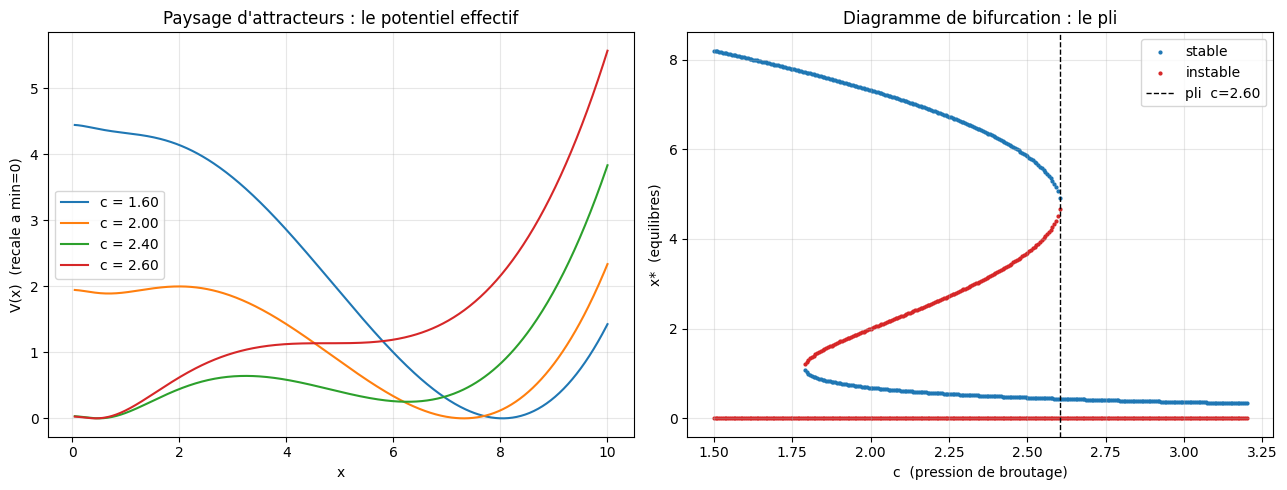

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# -- gauche : potentiel effectif V(x), recale a min=0 ; le puits haut s'aplatit --
xs = np.linspace(0.05, 10, 500)
for c in [1.6, 2.0, 2.4, c_fold]:
    V = modele.potential(xs, c)
    axL.plot(xs, V - V.min(), label=f"c = {c:.2f}")
axL.set_xlabel("x"); axL.set_ylabel("V(x)  (recale a min=0)")
axL.set_title("Paysage d'attracteurs : le potentiel effectif")
axL.legend(); axL.grid(alpha=0.3)

# -- droite : diagramme de bifurcation --
cg = np.linspace(1.5, 3.2, 300)
cs, xeq, st = modele.bifurcation_branches(cg)
axR.scatter(cs[st], xeq[st], s=4, color="C0", label="stable")
axR.scatter(cs[~st], xeq[~st], s=4, color="C3", label="instable")
axR.axvline(c_fold, ls="--", color="k", lw=1, label=f"pli  c={c_fold:.2f}")
axR.set_xlabel("c  (pression de broutage)"); axR.set_ylabel("x*  (equilibres)")
axR.set_title("Diagramme de bifurcation : le pli")
axR.legend(); axR.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Exercice 1 — la hauteur de la barriere

Le **col** qui protege l'etat haut a une hauteur $\Delta V = V(x_\text{instable}) - V(x_\text{haut})$.
*Fil metaphorique* : c'est la profondeur de la vallee haute — combien d'energie il faudrait pour en
sortir. *Fil de la mesure* : completez la fonction ci-dessous et **verifiez qu'elle tend vers 0 au pli**
(le puits s'aplatit). C'est une premiere lecture quantitative du « danger ».

*Indices :* `modele.equilibria(c)` renvoie `[(x, stable), ...]` ; l'etat haut est la plus grande racine
stable, le col est la racine instable ($x>0$) ; `modele.potential(x, c)` evalue $V$.


In [4]:
def hauteur_de_barriere(c):
    """Renvoie V(x_instable) - V(x_haut) : la hauteur du col protegeant l'etat haut.
    Doit tendre vers 0 au pli. Renvoyer None tant que l'exercice n'est pas complete."""
    # TODO etudiant : recuperer x_haut (plus grande racine stable) et x_instable (racine instable >0),
    #                 puis renvoyer modele.potential(x_instable, c) - modele.potential(x_haut, c)
    # eqs = modele.equilibria(c)
    # x_haut = max(x for x, st in eqs if st and x > 1e-6)
    # x_instable = [x for x, st in eqs if (not st) and x > 1e-6][0]
    # return float(modele.potential(x_instable, c) - modele.potential(x_haut, c))
    return None  # TODO

# Verification (a decommenter une fois l'exercice complete) :
# for c in [1.8, 2.2, 2.4, 2.55]:
#     print(f"c={c:.2f} : barriere = {hauteur_de_barriere(c):.4f}")
print("Exercice 1 a completer : la barriere du col doit decroitre vers 0 au pli.")

Exercice 1 a completer : la barriere du col doit decroitre vers 0 au pli.


## 3. Le ralentissement critique

Pres du pli, la **valeur propre** de l'equilibre haut (la pente $f'(x^*)$, force de rappel) tend vers
**zero** : le systeme **recupere de plus en plus lentement** de ses perturbations. C'est le mecanisme
physique qui *produit* les signaux precurseurs. On le voit de deux facons : (a) directement, $|f'(x^*)|
\to 0$ ; (b) une meme perturbation met plus longtemps a se resorber pres du pli.


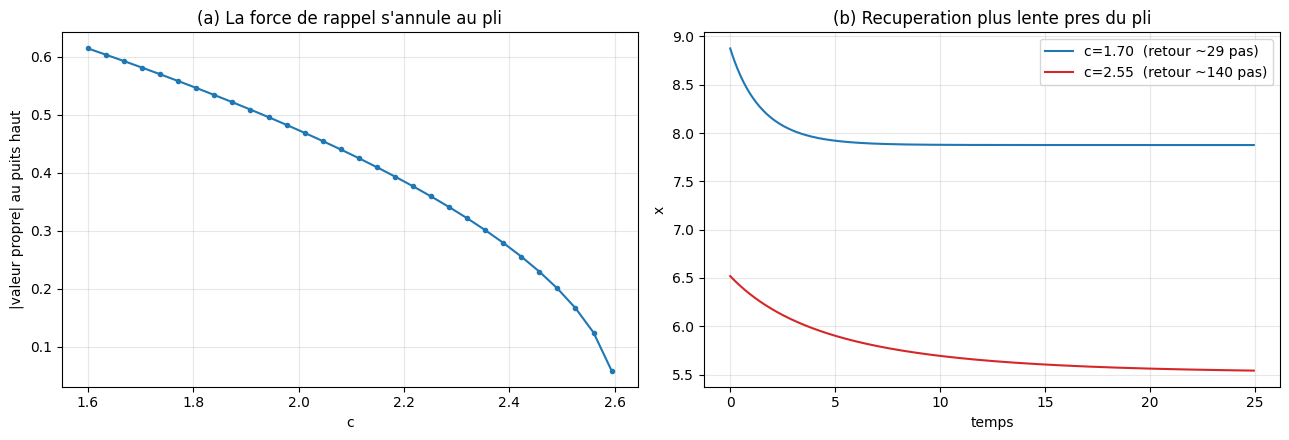

In [5]:
# (a) valeur propre locale au puits haut -> 0 au pli
cs_loc = np.linspace(1.6, c_fold - 0.01, 30)
lam = np.array([modele.rate_prime(max(x for x, st in modele.equilibria(c) if st), c) for c in cs_loc])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(cs_loc, -lam, "o-", ms=3)
a1.set_xlabel("c"); a1.set_ylabel("|valeur propre| au puits haut")
a1.set_title("(a) La force de rappel s'annule au pli"); a1.grid(alpha=0.3)

# (b) recuperation deterministe d'une meme perturbation (vers le haut), loin vs pres du pli
for c, col in [(1.7, "C0"), (c_fold - 0.05, "C3")]:
    xhigh = max(x for x, st in modele.equilibria(c) if st)
    x, dt, traj = xhigh + 1.0, 0.05, []
    for _ in range(500):
        traj.append(x); x = x + dt * float(modele.rate(x, c))
    traj = np.array(traj); t = np.arange(len(traj)) * dt
    rt = ew.recovery_time(traj, baseline=xhigh, tol=0.05 * xhigh)
    a2.plot(t, traj, color=col, label=f"c={c:.2f}  (retour ~{rt} pas)")
a2.set_xlabel("temps"); a2.set_ylabel("x")
a2.set_title("(b) Recuperation plus lente pres du pli"); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Les signaux precurseurs — variance et autocorrelation

Le ralentissement critique laisse **deux empreintes statistiques** dans les fluctuations d'un systeme
bruite, **avant** la bascule :

- la **variance** augmente (le systeme s'ecarte plus loin et plus longtemps de l'equilibre) ;
- l'**autocorrelation de retard 1 (AR1)** augmente (les ecarts persistent — la « memoire » s'allonge).

On applique le protocole canonique (Dakos/Scheffer) : a chaque $c$ **fixe** approchant le pli, une
simulation stochastique stationnaire, puis variance et AR1 des fluctuations (apres amincissement et
detrendage — on y revient juste apres). On attend que **les deux montent** vers le pli.


c=1.70  (pli-c = +0.90)   variance=0.00291   AR1=+0.7370
c=2.00  (pli-c = +0.60)   variance=0.00357   AR1=+0.7714
c=2.30  (pli-c = +0.30)   variance=0.00482   AR1=+0.8282
c=2.50  (pli-c = +0.10)   variance=0.00694   AR1=+0.8734
c=2.57  (pli-c = +0.03)   variance=0.01256   AR1=+0.9315

Tendance vers le pli :  variance  tau=+1.00 (p=1.4e-02)    AR1  tau=+1.00 (p=1.4e-02)


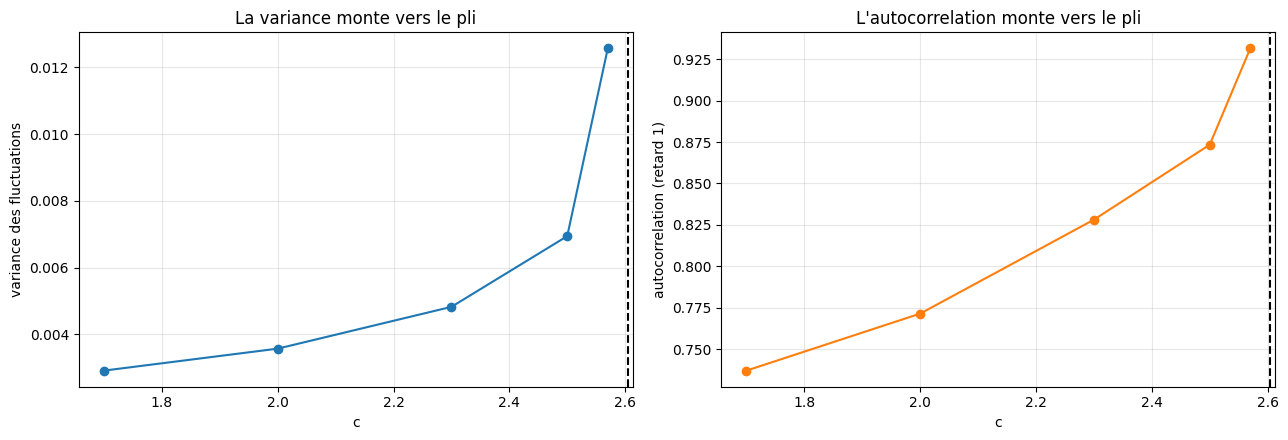

In [6]:
c_values = [1.7, 2.0, 2.3, 2.5, 2.57]
variances, ar1s = [], []
for c in c_values:
    xhigh = max(x for x, st in modele.equilibria(c) if st)
    serie = modele.simulate_sde(c=c, x0=xhigh, sigma=0.06, dt=0.01, T=300000,
                                seed=GRAINE + int(c * 100))
    s = ew.detrend(ew.thin(serie[50000:], factor=50), sigma=50)  # burn-in + thin + detrend
    variances.append(s.var()); ar1s.append(ew.lag1_autocorr(s))
variances, ar1s = np.array(variances), np.array(ar1s)

tau_v, p_v = ew.kendall_tau(c_values, variances)
tau_a, p_a = ew.kendall_tau(c_values, ar1s)
for c, v, a in zip(c_values, variances, ar1s):
    print(f"c={c:.2f}  (pli-c = {c_fold-c:+.2f})   variance={v:.5f}   AR1={a:+.4f}")
print(f"\nTendance vers le pli :  variance  tau={tau_v:+.2f} (p={p_v:.1e})"
      f"    AR1  tau={tau_a:+.2f} (p={p_a:.1e})")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(c_values, variances, "o-"); a1.axvline(c_fold, ls="--", color="k")
a1.set_xlabel("c"); a1.set_ylabel("variance des fluctuations")
a1.set_title("La variance monte vers le pli"); a1.grid(alpha=0.3)
a2.plot(c_values, ar1s, "o-", color="C1"); a2.axvline(c_fold, ls="--", color="k")
a2.set_xlabel("c"); a2.set_ylabel("autocorrelation (retard 1)")
a2.set_title("L'autocorrelation monte vers le pli"); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. *Sans complaisance* : la lecon de protocole

Voici le fil le plus important du notebook. Les deux indicateurs ci-dessus **ne se mesurent pas
naivement**. Sur **la meme serie** pres du pli :

- si on calcule l'AR1 sur la serie **brute** (pas d'integration tres fin devant le temps de relaxation),
  elle est **ecrasee pres de 1** et n'a **aucune marge** pour monter — le signal est **invisible**. Il
  faut **amincir** la serie a une cadence comparable au temps de relaxation ;
- si on calcule la variance **sans retirer la tendance**, on mesure la **derive deterministe** de
  l'equilibre, pas les **fluctuations** — on peut ainsi *fabriquer* un faux signal ou *masquer* le vrai.

Autrement dit : la metaphore « le systeme ralentit » n'est creditee que parce qu'on l'a **mesuree
correctement**. Une premiere mesure naive de ce notebook avait d'ailleurs echoue — c'est le protocole,
pas le substrat, qui etait en cause.


In [7]:
c = 2.55
xhigh = max(x for x, st in modele.equilibria(c) if st)
serie = modele.simulate_sde(c=c, x0=xhigh, sigma=0.06, dt=0.01, T=300000, seed=GRAINE)[50000:]

ar1_dense = ew.lag1_autocorr(serie)                  # brute (sur-echantillonnee)
ar1_thin  = ew.lag1_autocorr(ew.thin(serie, 50))     # amincie
var_brute    = serie.var()                           # tendance incluse
var_detrend  = ew.detrend(serie, sigma=2000).var()   # fluctuations seules

print(f"AR1 brute (sur-echantillonnee) = {ar1_dense:.4f}   <- saturee pres de 1, sans marge")
print(f"AR1 apres amincissement (x50)  = {ar1_thin:.4f}   <- le vrai signal se degage")
print(f"variance brute (tendance incluse)    = {var_brute:.5f}")
print(f"variance des fluctuations (detrendee) = {var_detrend:.5f}")
print("\nMeme systeme, meme instant : la mesure naive masque, le protocole correct revele.")

AR1 brute (sur-echantillonnee) = 0.9987   <- saturee pres de 1, sans marge
AR1 apres amincissement (x50)  = 0.9386   <- le vrai signal se degage
variance brute (tendance incluse)    = 0.01427
variance des fluctuations (detrendee) = 0.00980

Meme systeme, meme instant : la mesure naive masque, le protocole correct revele.


### Exercice 2 — les indicateurs stationnaires

Completez la fonction qui mesure les deux precurseurs a une pression $c$ **fixe**, par le protocole
stationnaire (simuler → retirer le *burn-in* → **amincir** → **detrendre** → variance & AR1). Vous
reproduirez ainsi, point par point, la courbe de la section 4.

*Indices :* l'etat de depart est l'etat haut ; `modele.simulate_sde(...)` ; pretraitement avec
`ew.thin(...)` puis `ew.detrend(...)` ; puis `.var()` et `ew.lag1_autocorr(...)`.


In [8]:
def indicateurs_a(c, sigma=0.06, T=200000, seed=0):
    """Renvoie (variance, AR1) des fluctuations a la pression c, protocole stationnaire.
    Renvoyer None tant que l'exercice n'est pas complete."""
    # TODO etudiant :
    # x0 = max(x for x, st in modele.equilibria(c) if st)
    # serie = modele.simulate_sde(c=c, x0=x0, sigma=sigma, dt=0.01, T=T, seed=seed)
    # s = ew.detrend(ew.thin(serie[T//6:], factor=50), sigma=50)
    # return float(s.var()), float(ew.lag1_autocorr(s))
    return None  # TODO

# Verification (a decommenter une fois complete) :
# for c in [1.8, 2.3, 2.55]:
#     print(c, indicateurs_a(c))
print("Exercice 2 a completer : indicateurs stationnaires (variance, AR1) a c fixe.")

Exercice 2 a completer : indicateurs stationnaires (variance, AR1) a c fixe.


## 6. Le scenario reel — une rampe non-stationnaire

Dans la nature, $c$ ne saute pas : il **derive lentement**. On fait donc glisser $c$ de 1.7 a 2.9
(la rampe traverse le pli) et on demande : **les precurseurs montent-ils AVANT la bascule** ? C'est tout
l'enjeu pratique des EWS — donner l'alerte pendant qu'il est encore temps.


Bascule a t=184446  (c_tip=2.622, pli a 2.604)
Avant la bascule :  variance tau=+0.347 (p=1.9e-237)    AR1 tau=+0.303 (p=5.8e-182)


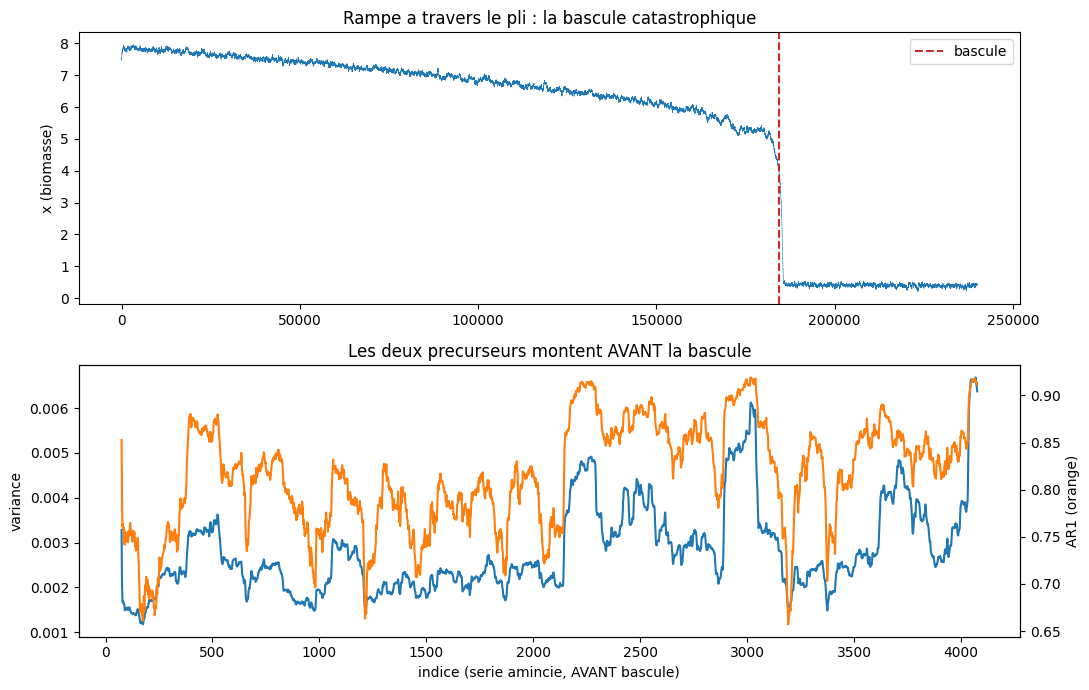

In [9]:
xs_ramp, cs_ramp = modele.simulate_ramp(c0=1.7, c1=2.9, x0=7.5, sigma=0.05,
                                        dt=0.01, T=240000, seed=GRAINE)
seuil = 0.5 * xs_ramp[:2000].mean()
tip = int(np.argmax(xs_ramp < seuil))
print(f"Bascule a t={tip}  (c_tip={cs_ramp[tip]:.3f}, pli a {c_fold:.3f})")

pre = xs_ramp[: int(tip * 0.90)]                       # fenetre AVANT la bascule
out = ew.ews_summary(pre, window=150, thin_factor=40, detrend_sigma=40)
print(f"Avant la bascule :  variance tau={out['tau_var']:+.3f} (p={out['p_var']:.1e})"
      f"    AR1 tau={out['tau_ar1']:+.3f} (p={out['p_ar1']:.1e})")

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].plot(xs_ramp, lw=0.4); ax[0].axvline(tip, color="C3", ls="--", label="bascule")
ax[0].set_ylabel("x (biomasse)"); ax[0].legend()
ax[0].set_title("Rampe a travers le pli : la bascule catastrophique")
ax[1].plot(out["index"], out["variance"], label="variance roulante")
axb = ax[1].twinx(); axb.plot(out["index"], out["ar1"], color="C1")
ax[1].set_xlabel("indice (serie amincie, AVANT bascule)")
ax[1].set_ylabel("variance"); axb.set_ylabel("AR1 (orange)")
ax[1].set_title("Les deux precurseurs montent AVANT la bascule")
plt.tight_layout(); plt.show()

### Exercice 3 — avertissement contre vitesse de derive

Un systeme qui derive **vite** laisse **moins de temps** au precurseur pour s'etablir : l'alerte est plus
faible, ou arrive trop tard. Completez la fonction qui renvoie la tendance `tau_var` mesuree avant la
bascule pour une rampe de duree $T$, et **comparez une rampe lente (T grand) a une rampe rapide
(T petit)**.

*Indices :* `modele.simulate_ramp(c0=1.7, c1=2.9, x0=7.5, sigma=0.05, dt=0.01, T=T, seed=GRAINE)` ;
detecter la bascule (seuil = moitie de la moyenne initiale) ; `ew.ews_summary(pre, ...)`.


In [10]:
def avertissement_vs_vitesse(T):
    """Renvoie le tau_var mesure AVANT la bascule pour une rampe de duree T.
    Renvoyer None tant que l'exercice n'est pas complete."""
    # TODO etudiant :
    # xs, cs = modele.simulate_ramp(c0=1.7, c1=2.9, x0=7.5, sigma=0.05, dt=0.01, T=T, seed=GRAINE)
    # seuil = 0.5 * xs[:max(2000, T//100)].mean()
    # tip = int(np.argmax(xs < seuil))
    # pre = xs[: int(tip * 0.90)]
    # return ew.ews_summary(pre, window=120, thin_factor=20, detrend_sigma=40)["tau_var"]
    return None  # TODO

# Verification (a decommenter) : rampe lente vs rapide
# print("lente  (T=240000):", avertissement_vs_vitesse(240000))
# print("rapide (T= 60000):", avertissement_vs_vitesse(60000))
print("Exercice 3 a completer : comparer l'avertissement pour une rampe lente vs rapide.")

Exercice 3 a completer : comparer l'avertissement pour une rampe lente vs rapide.


## 7. Pont vers la causal emergence (ICT-5/6) et vers ICT-9

Les deux vallees du paysage forment un **gros-grain** naturel a deux macro-etats — *bas* (surpature) et
*haut* (vegetalise) — separes par le col instable. C'est exactement le type de **coarse-graining** que
les notebooks [ICT-5](ICT-5-CausalEmergence.ipynb) et [ICT-6](ICT-6-SortingToTPM-CausalEmergence.ipynb)
analysent : on peut estimer une chaine de Markov a deux etats depuis une trajectoire bruitee et
mesurer, via l'**information effective**, *quelle echelle fait le plus de travail causal*. Loin du pli,
la description macro est quasi-deterministe (on reste dans sa vallee) ; pres du pli, la barriere
s'effondre et les **escapes** se multiplient — la meme physique qui fait monter les precurseurs.

C'est la **continuite** de la serie : la machinerie causale de la strate 1 s'applique telle quelle a la
dynamique generative de la strate 2.

**Vers ICT-9 — l'agence.** Ici, le systeme *subit* son paysage : il bascule quand on le pousse. Le
prochain notebook leve la limite restante du marche-pied — le **but extrinseque** — en passant a la
**morphogenese reaction-diffusion regenerante** : un systeme qui **repare** sa forme vers un *point de
consigne intrinseque* apres ablation. L'agence s'y demontrera **par contraste** (la reaction repare la
ou la simple diffusion dissout), comme le « sans liberte, pas d'agregation » d'ICT-4.


## Conclusion — la metaphore tenue par la mesure

On a tresse deux fils tout du long :

| Le fil metaphorique | Le fil de la mesure |
|---|---|
| un paysage a deux vallees | deux equilibres stables + un col, racines du champ |
| la vallee haute s'aplatit | le potentiel effectif $V(x)$ et sa barriere $\Delta V \to 0$ |
| le systeme « hesite » au bord | la valeur propre $\to 0$, la recuperation ralentit |
| le systeme « se souvient » du danger | variance ↑ et autocorrelation ↑ (tau de Kendall positifs) |
| une alerte avant la catastrophe | les precurseurs montent **avant** la bascule de la rampe |

Et surtout : la metaphore n'est **credible que parce que le protocole est rigoureux** — amincir,
detrendre, tester la tendance. Mesures naives = signaux fantomes. C'est la version dynamique de la these
de Levin : une competence (« anticiper sa propre catastrophe ») n'est creditee qu'au vu de ce qu'une
experience explicite en mesure.

**Ce que ce notebook a apporte par rapport au tri** : un **vrai paysage d'attracteurs** (plusieurs
bassins, une bifurcation) la ou le tri n'avait qu'un attracteur unique a but impose. Il reste a faire
emerger l'**agence** — un systeme qui maintient *lui-meme* sa forme. C'est l'objet d'**ICT-9**.
